In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [15]:
df = pd.read_csv('data.csv')

In [16]:
# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [17]:
# Step 1: Generate Synthetic House Price Dataset (similar to real estate data)
np.random.seed(42)
n_samples = 1000

data = {
    'size_sqft': np.random.normal(2000, 500, n_samples),  # Square footage
    'bedrooms': np.random.randint(1, 6, n_samples),
    'bathrooms': np.random.randint(1, 4, n_samples),
    'lot_size': np.random.normal(8000, 2000, n_samples),
    'year_built': np.random.randint(1950, 2020, n_samples),
    'location_score': np.random.uniform(1, 10, n_samples),  # 1=poor, 10=excellent
    'garage': np.random.choice([0, 1, 2], n_samples, p=[0.3, 0.5, 0.2]),
    'pool': np.random.choice([0, 1], n_samples, p=[0.85, 0.15])
}

In [18]:
# Generate realistic prices based on features
price_base = (data['size_sqft'] * 150 + 
              data['bedrooms'] * 50000 + 
              data['bathrooms'] * 30000 + 
              data['lot_size'] * 2 + 
              (2023 - data['year_built']) * 2000 + 
              data['location_score'] * 20000 + 
              data['garage'] * 25000 + 
              data['pool'] * 15000)

data['price'] = np.maximum(price_base + np.random.normal(0, 50000, n_samples), 50000)

df = pd.DataFrame(data)
df = df[(df['size_sqft'] > 500) & (df['size_sqft'] < 5000)]  # Clean outliers

print("Dataset Overview:")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"\nPrice statistics:\n{df['price'].describe()}")


Dataset Overview:
     size_sqft  bedrooms  bathrooms      lot_size  year_built  location_score  \
0  2248.357077         4          3   7798.523509        2003        8.928056   
1  1930.867849         1          3   6912.256268        1979        1.446453   
2  2323.844269         3          1  10071.166575        1994        3.313564   
3  2761.514928         5          3   6428.640807        1968        5.185327   
4  1882.923313         3          3   8911.237239        1983        3.042807   

   garage  pool         price  
0       1     0  9.193594e+05  
1       0     0  5.380671e+05  
2       1     0  7.165605e+05  
3       1     0  1.030560e+06  
4       1     0  7.257728e+05  

Dataset shape: (999, 9)

Price statistics:
count    9.990000e+02
mean     7.387353e+05
std      1.346565e+05
min      3.517269e+05
25%      6.478079e+05
50%      7.341613e+05
75%      8.315538e+05
max      1.176236e+06
Name: price, dtype: float64


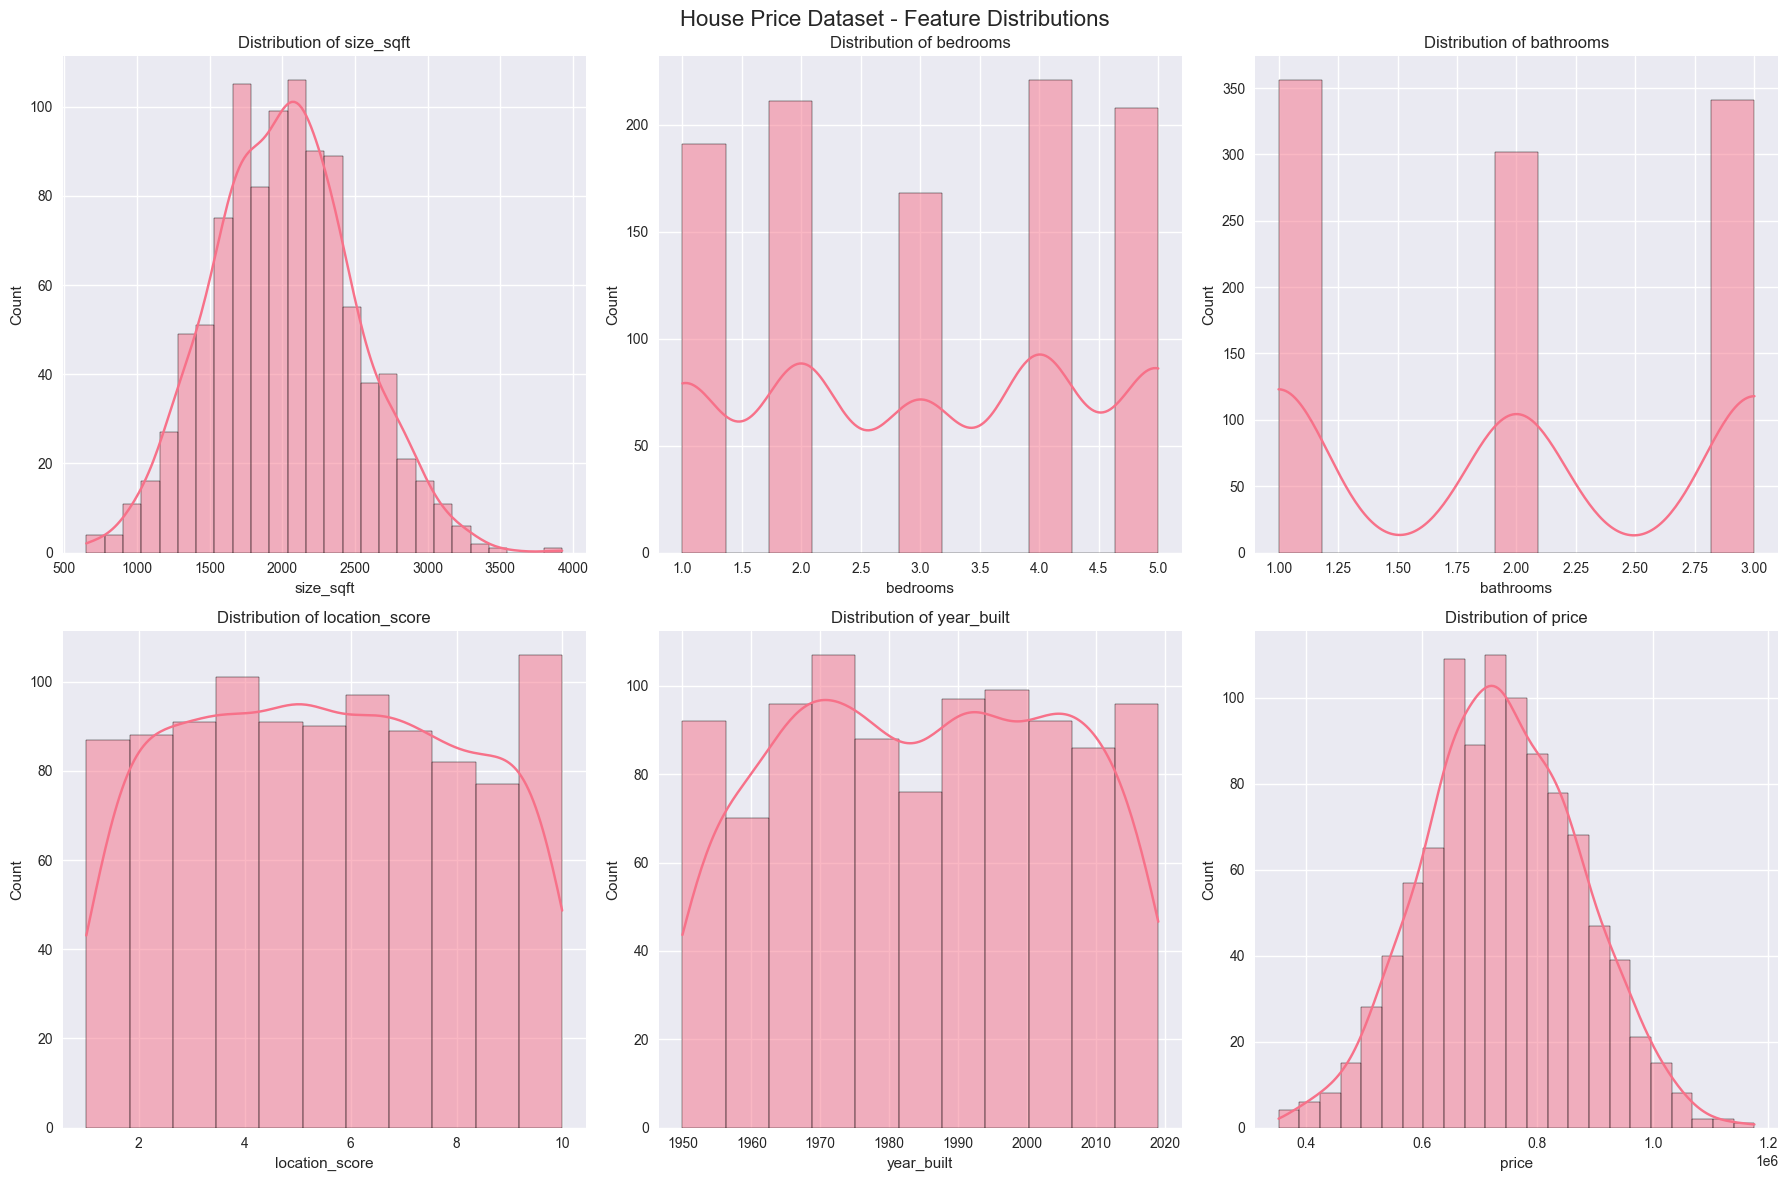

In [19]:
# Step 2: Exploratory Data Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('House Price Dataset - Feature Distributions', fontsize=16)

features = ['size_sqft', 'bedrooms', 'bathrooms', 'location_score', 'year_built', 'price']
for i, feature in enumerate(features):
    row, col = i // 3, i % 3
    sns.histplot(data=df, x=feature, kde=True, ax=axes[row, col])
    axes[row, col].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

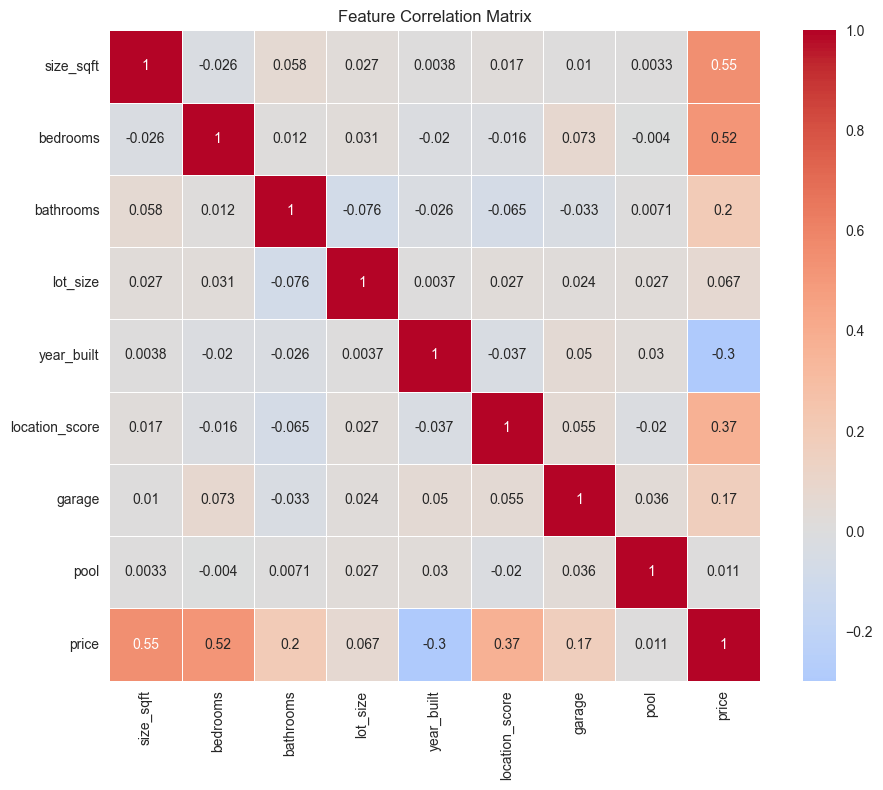

In [20]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [21]:
# Step 3: Data Preprocessing
X = df.drop('price', axis=1)
y = df['price']

In [22]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")


Training set size: (799, 8)
Test set size: (200, 8)


In [24]:
# Step 4: Train Multiple Models
models = {
    'Linear Regression': LinearRegression(),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

model_results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Evaluation metrics
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_r2 = r2_score(y_test, y_pred_test)
    
    model_results[name] = {
        'model': model,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    }
    
    print(f"\n{name}:")
    print(f"  Train MAE: ${train_mae:,.0f}")
    print(f"  Test MAE: ${test_mae:,.0f}")
    print(f"  Test RMSE: ${test_rmse:,.0f}")
    print(f"  Test R²: {test_r2:.3f}")


Linear Regression:
  Train MAE: $41,622
  Test MAE: $39,463
  Test RMSE: $49,634
  Test R²: 0.831

Gradient Boosting:
  Train MAE: $31,107
  Test MAE: $43,829
  Test RMSE: $54,037
  Test R²: 0.800


In [25]:
# Step 5: Model Comparison
results_df = pd.DataFrame(model_results).T
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(results_df[['test_mae', 'test_rmse', 'test_r2']].round(2))

# Select best model (lowest test MAE)
best_model_name = results_df['test_mae'].idxmin()
best_model = model_results[best_model_name]['model']
print(f"\n Best Model: {best_model_name}")


MODEL COMPARISON
                       test_mae     test_rmse   test_r2
Linear Regression  39462.903785  49634.118521  0.831408
Gradient Boosting   43828.87727  54036.937251  0.800171

 Best Model: Linear Regression


Text(0.5, 0.98, 'Linear Regression - Model Performance')

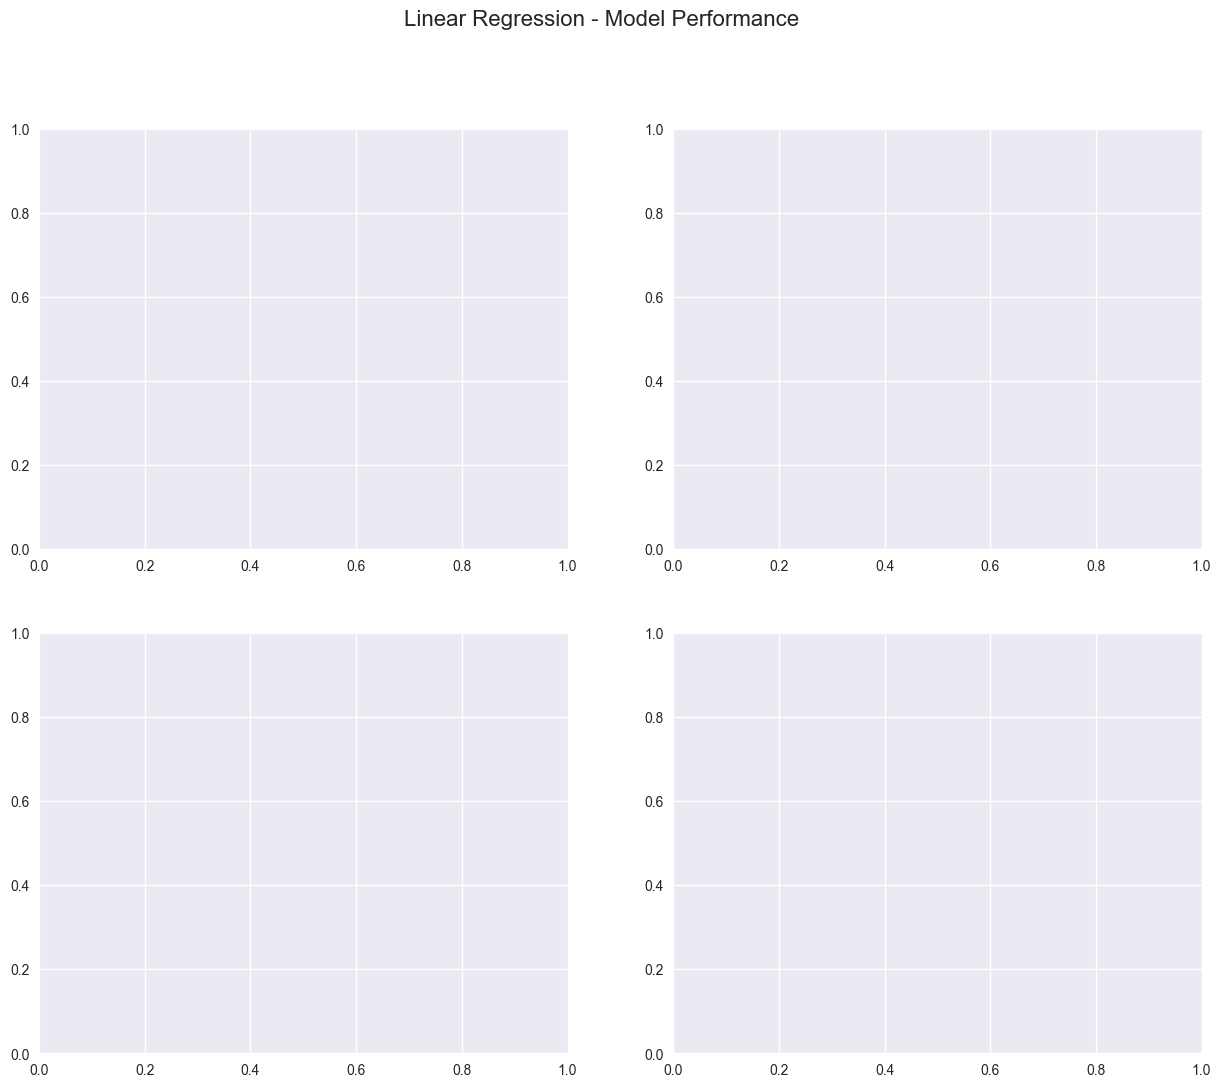

In [26]:
# Step 6: Visualization - Predicted vs Actual Prices
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'{best_model_name} - Model Performance', fontsize=16)

In [27]:
# 1. Predicted vs Actual (Test set)
y_pred_best = best_model.predict(X_test)
axes[0,0].scatter(y_test, y_pred_best, alpha=0.6, color='skyblue')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Price ($)')
axes[0,0].set_ylabel('Predicted Price ($)')
axes[0,0].set_title('Predicted vs Actual Prices\n(Test Set)')


Text(0.5, 1.0, 'Predicted vs Actual Prices\n(Test Set)')

In [28]:
# 2. Residuals plot
residuals = y_test - y_pred_best
axes[0,1].scatter(y_pred_best, residuals, alpha=0.6, color='orange')
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Predicted Price ($)')
axes[0,1].set_ylabel('Residuals ($)')
axes[0,1].set_title('Residuals Plot')

Text(0.5, 1.0, 'Residuals Plot')

In [29]:
# 3. Price prediction error distribution
axes[1,0].hist(residuals, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1,0].axvline(residuals.mean(), color='red', linestyle='--', linewidth=2)
axes[1,0].set_xlabel('Prediction Error ($)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title(f'Residuals Distribution\nMean Error: ${residuals.mean():,.0f}')

Text(0.5, 1.0, 'Residuals Distribution\nMean Error: $-1,087')

In [30]:
# 4. Feature importance (for Gradient Boosting)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = best_model.feature_importances_
    features = X.columns
    importance_df = pd.DataFrame({'feature': features, 'importance': feature_importance})
    importance_df = importance_df.sort_values('importance', ascending=True)
    
    sns.barh(importance_df['feature'], importance_df['importance'], ax=axes[1,1])
    axes[1,1].set_title('Feature Importance')
    axes[1,1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

<Figure size 800x550 with 0 Axes>

In [31]:
# Step 7: Business Insights - Price Prediction for New Houses
print("\n" + "="*60)
print("BUSINESS INSIGHTS")
print("="*60)


BUSINESS INSIGHTS


In [32]:
# Example predictions for different house types
new_houses = pd.DataFrame({
    'size_sqft': [1500, 2500, 3500, 1200],
    'bedrooms': [3, 4, 5, 2],
    'bathrooms': [2, 3, 3, 1],
    'lot_size': [6000, 10000, 15000, 4000],
    'year_built': [2005, 2015, 1990, 1980],
    'location_score': [8.5, 9.2, 6.8, 7.5],
    'garage': [2, 2, 1, 1],
    'pool': [0, 1, 1, 0]
})

new_houses_scaled = scaler.transform(new_houses)
predicted_prices = best_model.predict(new_houses_scaled)

new_houses['predicted_price'] = predicted_prices
print("\nPredicted Prices for New Listings:")
print(new_houses[['size_sqft', 'bedrooms', 'location_score', 'predicted_price']].round(0))



Predicted Prices for New Listings:
   size_sqft  bedrooms  location_score  predicted_price
0       1500         3             8.0         701968.0
1       2500         4             9.0         945210.0
2       3500         5             7.0        1134208.0
3       1200         2             8.0         572120.0


In [33]:
# Summary statistics
print(f"\n📊 FINAL MODEL PERFORMANCE ({best_model_name}):")
print(f"   MAE:  ${model_results[best_model_name]['test_mae']:,.0f} (±{np.std(residuals):,.0f})")
print(f"   RMSE: ${model_results[best_model_name]['test_rmse']:,.0f}")
print(f"   R²:   {model_results[best_model_name]['test_r2']:.3f}")
print(f"   Price Range: ${y_test.min():,.0f} - ${y_test.max():,.0f}")


📊 FINAL MODEL PERFORMANCE (Linear Regression):
   MAE:  $39,463 (±49,622)
   RMSE: $49,634
   R²:   0.831
   Price Range: $402,662 - $1,051,104
